In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [11]:
import pandas as pd   # Import pandas with alias 'pd'

data = pd.read_csv("IRIS.csv")

print(data.head())


   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [19]:
data.drop(['Species'], axis=1, inplace=True, errors='ignore')


In [13]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


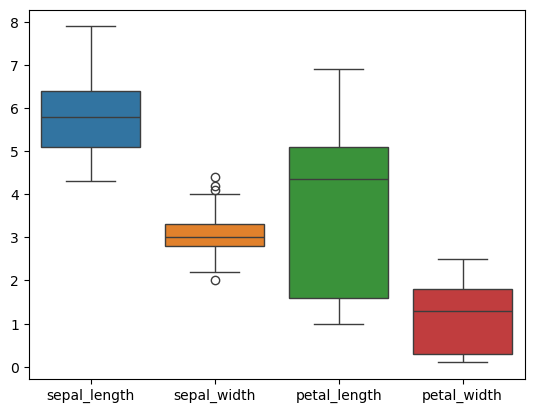

In [14]:
sns.boxplot(data = data)
plt.show()

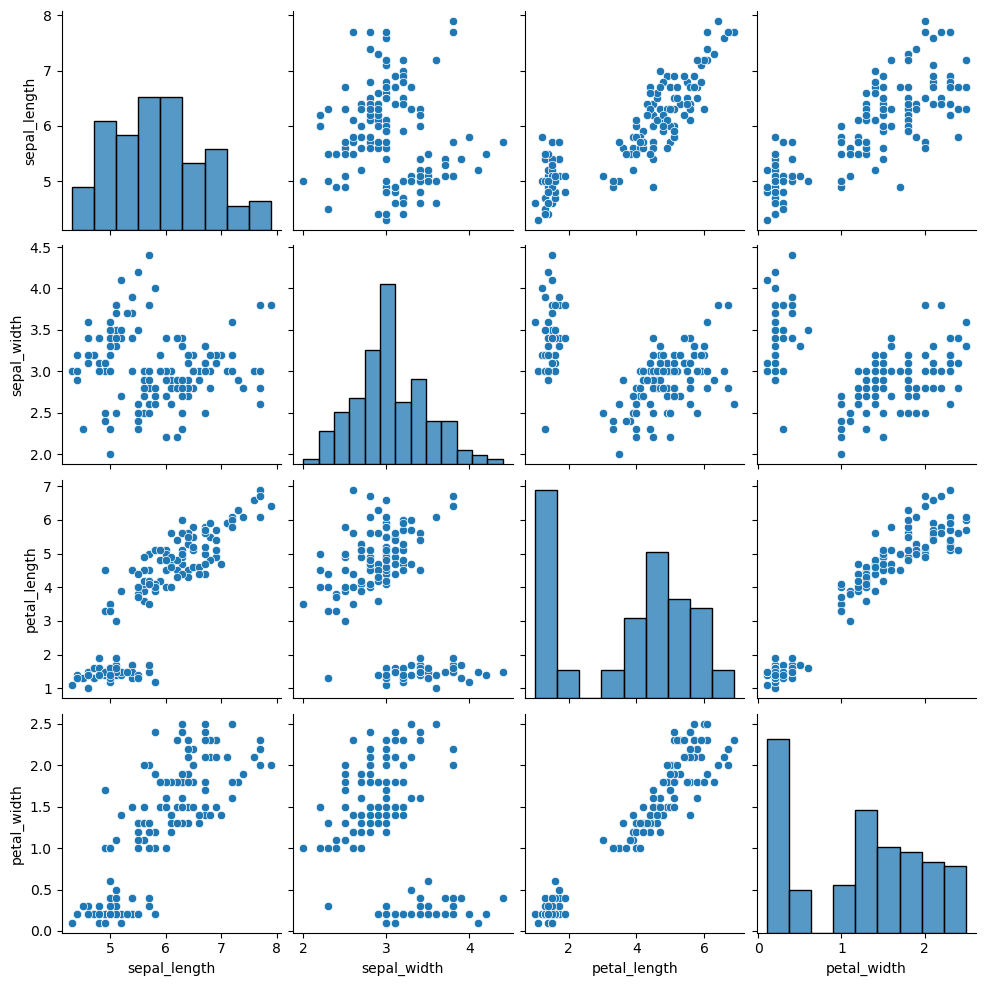

In [15]:
sns.pairplot(data = data)
plt.show()

In [20]:
wcss = []
for i in range (2,22):
    km = KMeans(n_clusters = i, init = 'k-means++')
    km.fit(data)
    wcss.append(km.inertia_)

ValueError: could not convert string to float: 'Iris-setosa'

In [ ]:
plt.figure(figsize = (15,5))
plt.plot([i for i in range (2,22)], wcss, marker = 'o')
plt.xticks([i for i in range (2,22)])
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.grid(axis = 'x')
plt.savefig('Cluster.jpg')
plt.show()

In [ ]:
kms = KMeans(n_clusters = 3)
data['predict'] = kms.fit_predict(data)

In [18]:
from sklearn.cluster import KMeans

# Create and fit the model
kms = KMeans(n_clusters=3, random_state=42)
kms.fit(data)   # 'data' should be your dataset

# Now you can access the cluster labels
print(kms.labels_)


ValueError: could not convert string to float: 'Iris-setosa'

In [87]:
from sklearn.metrics import silhouette_score

In [94]:
silhouette_score(data, labels = kms.labels_)

0.684936462996038

In [107]:
ss = []
no_c = [j for j in range(2,21)]
for i in range (2,21):
    km1 = KMeans(n_clusters = i)
    km1.fit(data)
    ss.append(silhouette_score(data,km1.labels_))
    

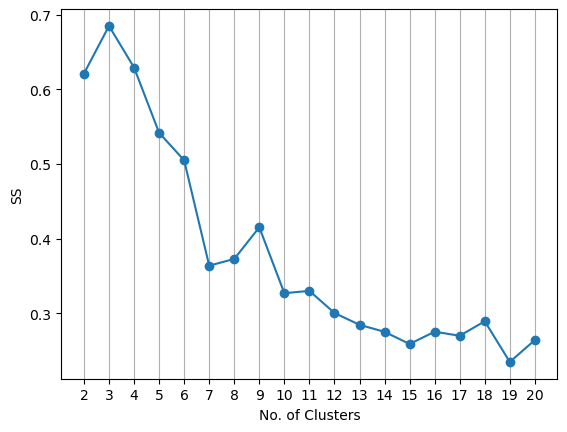

In [110]:
plt.plot(no_c,ss, marker = 'o')
plt.xticks(no_c)
plt.xlabel('No. of Clusters')
plt.ylabel('SS')
plt.grid(axis = 'x')
plt.show()

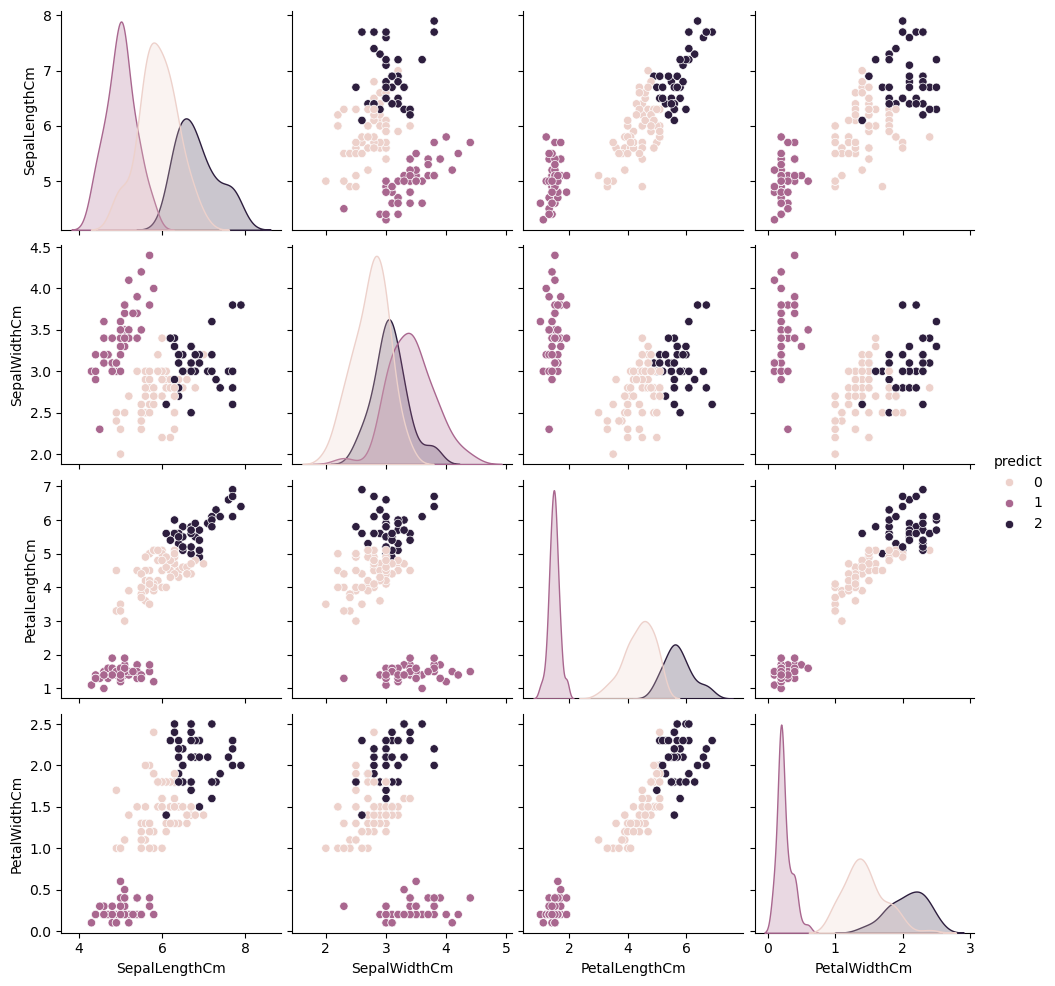

In [93]:
sns.pairplot(data = data, hue = 'predict')
plt.savefig('pred.jpg')
plt.show()

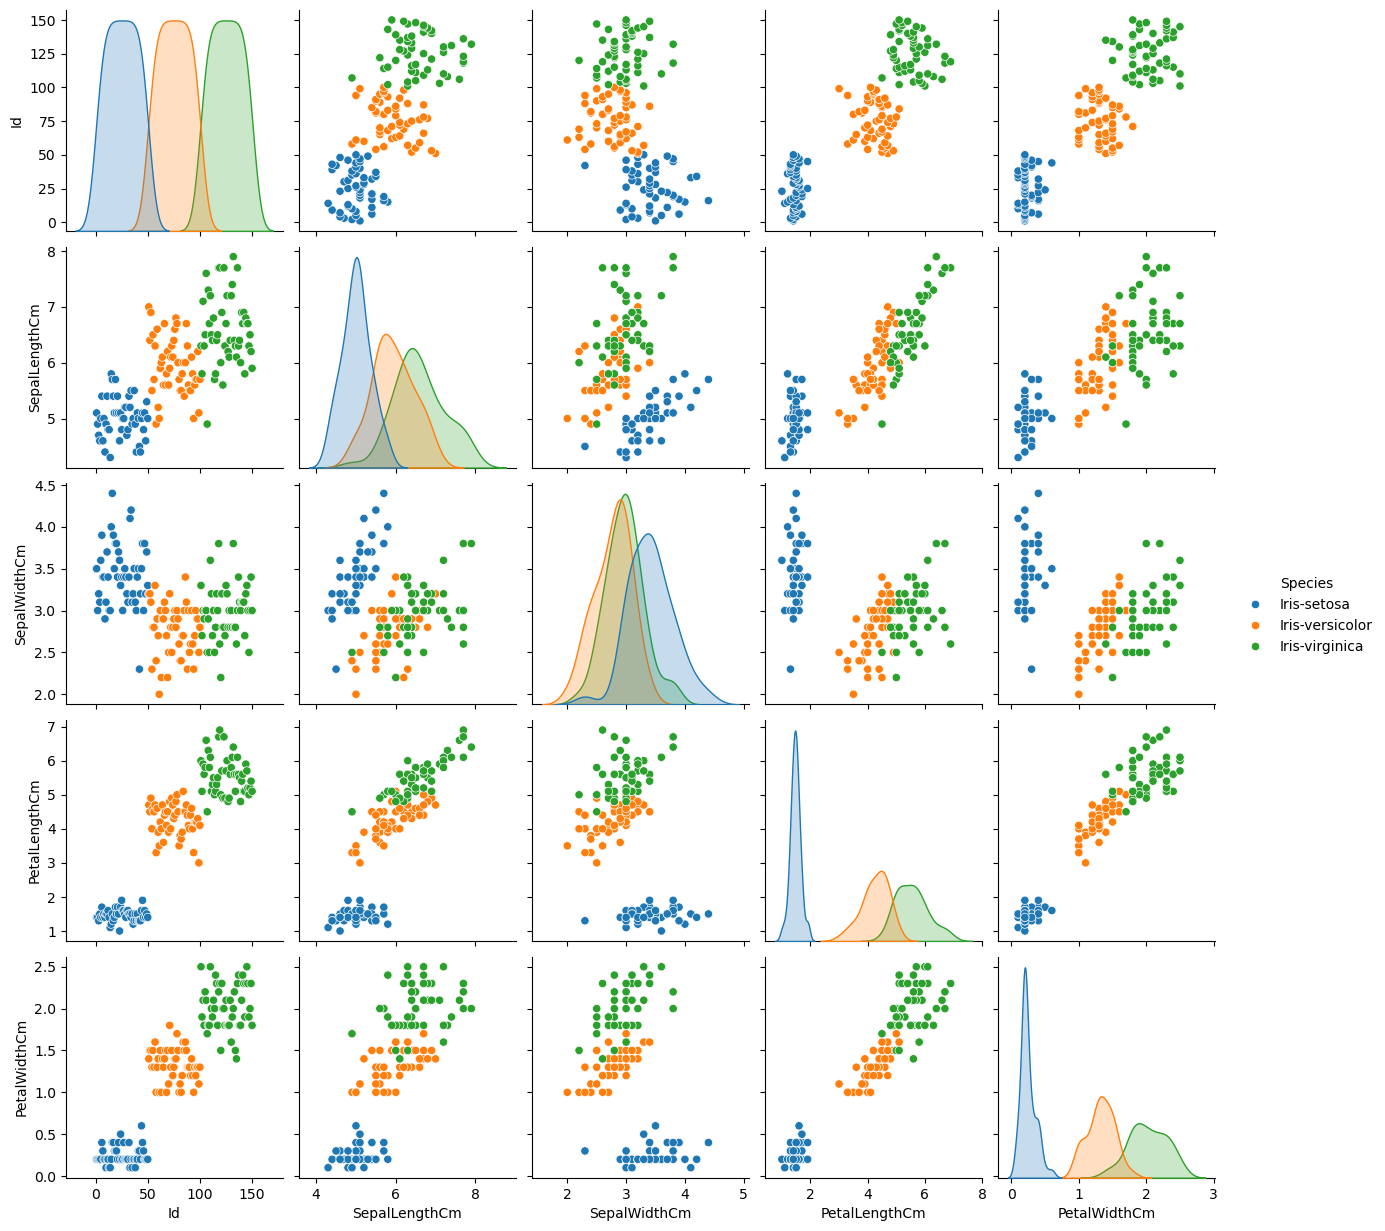

In [35]:
org_data = pd.read_csv('Iris.csv')
sns.pairplot(data = org_data, hue = 'Species')
plt.savefig('org_fig.jpg')
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('Iris.csv')
data.drop(['Species'], axis = 1, inplace  = True)
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


<function matplotlib.pyplot.show(close=None, block=None)>

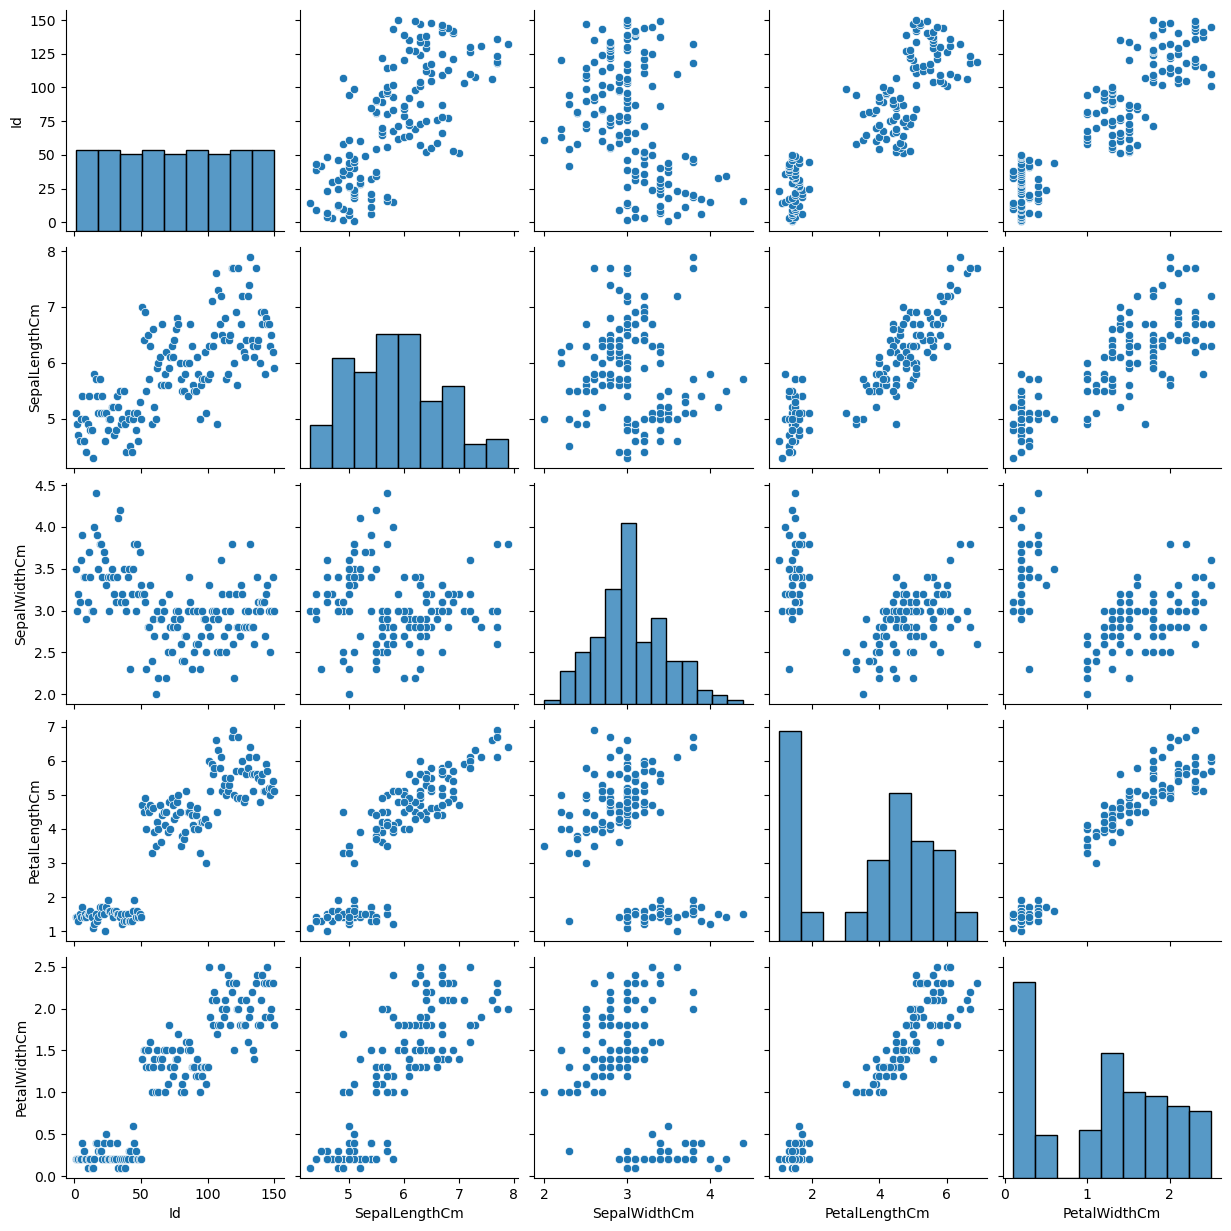

In [5]:
sns.pairplot(data = data)
plt.show

In [24]:
import scipy.cluster.hierarchy as sc # Hierarchical clustering is working on the using distance the the outcome is different if the data are more clear than it predict clear.

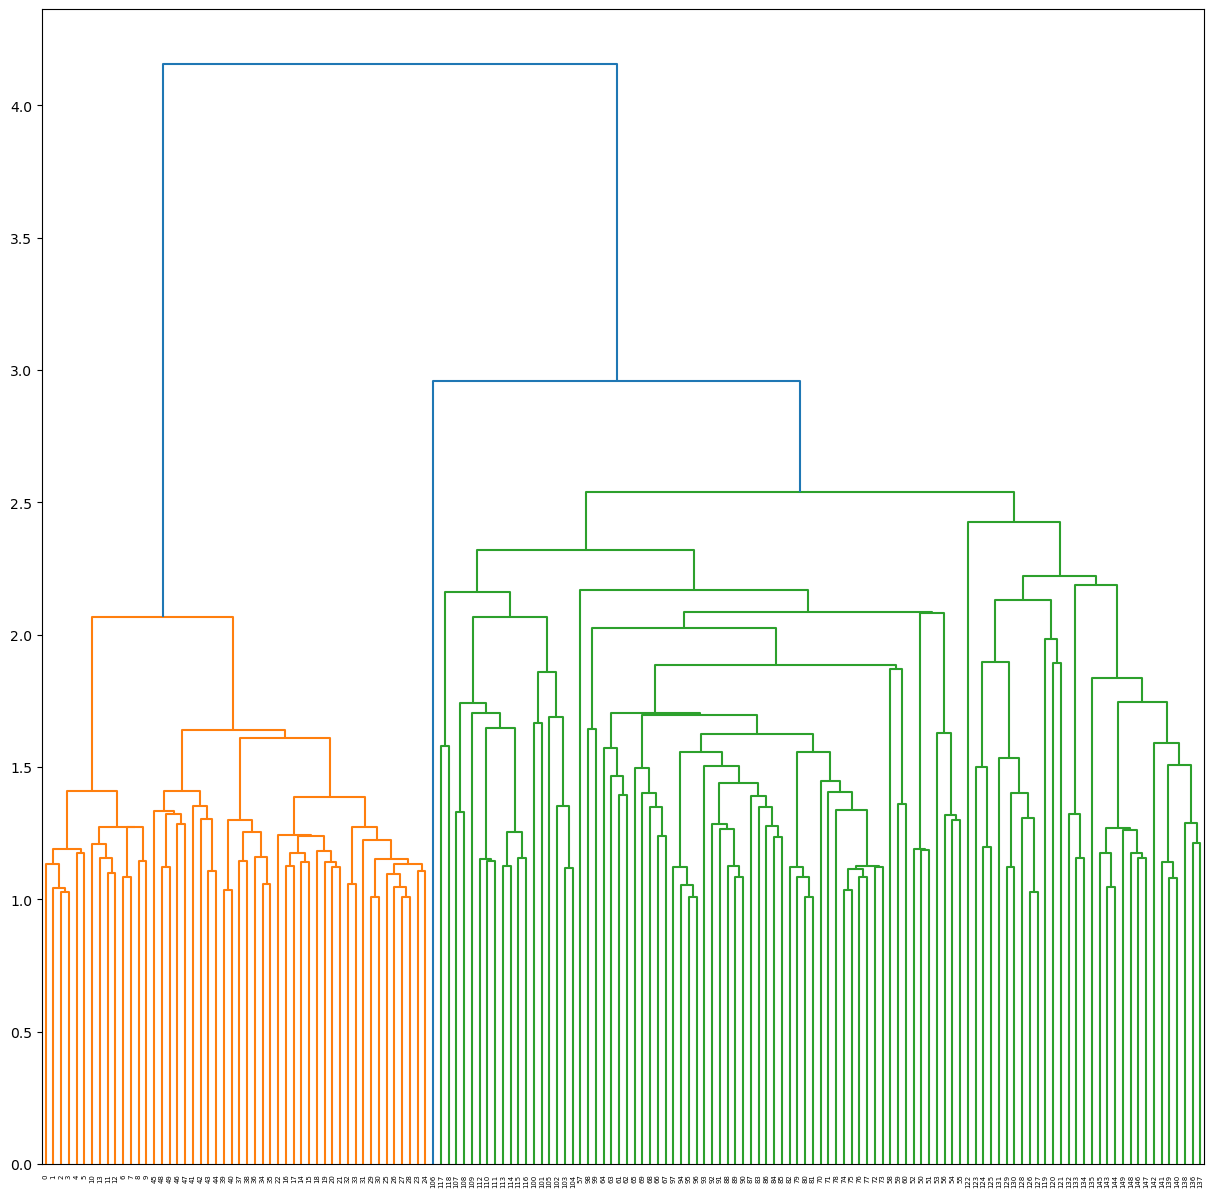

In [12]:
plt.figure(figsize = (15,15))
sc.dendrogram(sc.linkage(data,method = 'single', metric ='euclidean'))
plt.savefig('dendrogram.jpg')
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [20]:
agg = AgglomerativeClustering(n_clusters = 2, linkage = 'single')
data['predict'] = agg.fit_predict(data)

In [21]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,predict
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1


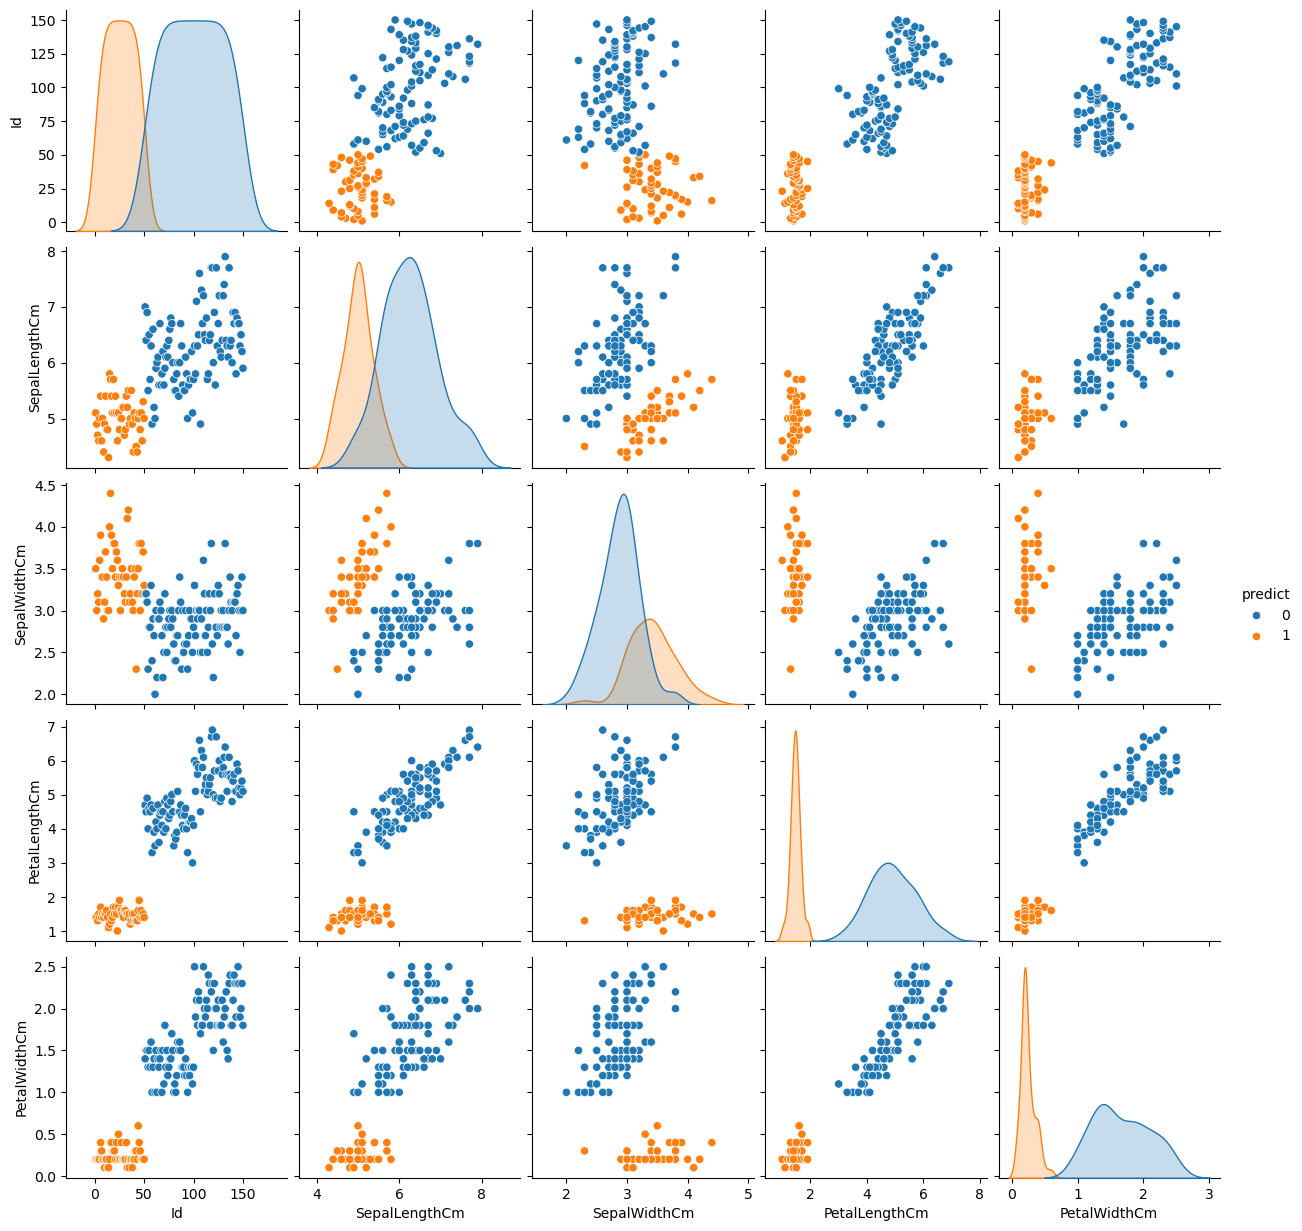

In [23]:
sns.pairplot(data =data, hue = 'predict')
plt.show()

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [62]:
X,Y = make_moons(n_samples = 200, noise = 0.02)

In [75]:
df = {'d1':X[:,0], "d2":X[:,1]}

In [ ]:
data = pd.DataFrame(df)

In [68]:
data.head()

,d1,d2
0,0.193624,0.955394
1,-0.175634,0.946698
2,1.671005,-0.230053
3,0.195751,0.948865
4,-0.885299,0.528017


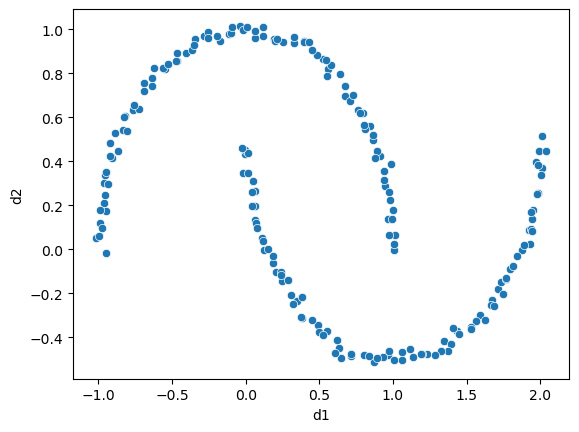

In [69]:
sns.scatterplot(x = 'd1', y = 'd2', data = data)
plt.show()

In [70]:
dn = DBSCAN(eps = 0.2, min_samples = 5)
data['predict'] = dn.fit_predict(data)

In [71]:
data.head(3)

,d1,d2,predict
0,0.193624,0.955394,0
1,-0.175634,0.946698,0
2,1.671005,-0.230053,1


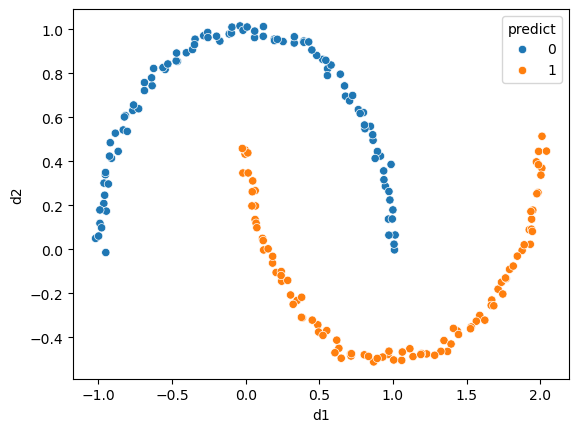

In [73]:
sns.scatterplot(x = 'd1', y = 'd2', data = data, hue = 'predict')
plt.show()

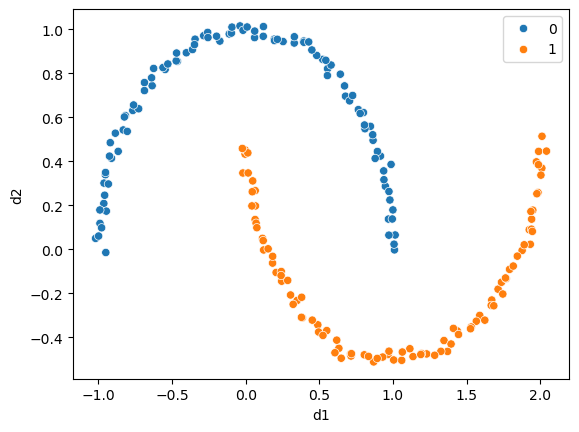

In [76]:
sns.scatterplot(x = 'd1', y = 'd2', data = data, hue = Y)
plt.show()

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('groceries.csv')
data.head()

,citrus fruit,semi-finished bread,margarine,ready soups,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
pd.set_option("display.max_rows",170)

In [3]:
data.shape

(9834, 32)

In [4]:
market = []
for i in range (0,data.shape[0]):
    cus = []
    for j in data.columns:
        if type(data[j][i]) == str:
            cus.append(data[j][i])
    market.append(cus)

In [5]:
l = []
for i in market:
    for j in i:
        l.append(j)

In [6]:
import collections

In [7]:
p = collections.Counter(l)

In [32]:
df = {"Item Name":p.keys(),'Values':p.values()}

In [33]:
pd.DataFrame(df).sort_values(by = ['Values'],ascending =False)

,Item Name,Values
3,whole milk,2513
7,other vegetables,1903
13,rolls/buns,1809
28,soda,1715
1,yogurt,1372
20,bottled water,1087
39,root vegetables,1072
0,tropical fruit,1032
49,shopping bags,969
47,sausage,924


In [22]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [24]:
te = TransactionEncoder()
te.fit(market)

TransactionEncoder()

In [25]:
df = pd.DataFrame(te.transform(market),columns = te.columns_)

In [26]:
df

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9830,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [30]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True, max_len=3).sort_values(by = ['support'])
print(frequent_itemsets)

     support                        itemsets
13  0.052369                       (napkins)
0   0.052471                          (beef)
8   0.053285                          (curd)
4   0.055420                        (butter)
30  0.056030            (yogurt, whole milk)
29  0.056640        (rolls/buns, whole milk)
18  0.057657                          (pork)
7   0.058064                        (coffee)
12  0.058471                     (margarine)
10  0.058979                   (frankfurter)
9   0.063453                 (domestic eggs)
3   0.064877                   (brown bread)
25  0.071690            (whipped/sour cream)
11  0.072300         (fruit/vegetable juice)
28  0.074842  (other vegetables, whole milk)
17  0.075656                     (pip fruit)
5   0.077690                   (canned beer)
14  0.079825                    (newspapers)
1   0.080537                  (bottled beer)
6   0.082672                  (citrus fruit)
16  0.088977                        (pastry)
21  0.0939

In [57]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# Replace this with your actual df dict
df_dict = {
    'transaction1': ['bread', 'milk'],
    'transaction2': ['bread', 'diaper', 'beer'],
    'transaction3': ['milk', 'diaper', 'beer'],
    'transaction4': ['bread', 'milk', 'diaper']
}

# Convert to DataFrame
te = TransactionEncoder()
te_ary = te.fit(list(df_dict.values())).transform(list(df_dict.values()))
df = pd.DataFrame(te_ary, columns=te.columns_)

# Now run apriori
apriori(df, min_support=0.07, use_colnames=True, max_len=3)

,support,itemsets
0,0.50,(beer)
1,0.75,(bread)
2,0.75,(diaper)
3,0.75,(milk)
4,0.25,"(beer, bread)"
5,0.50,"(diaper, beer)"
6,0.25,"(beer, milk)"
7,0.50,"(diaper, bread)"
8,0.50,"(milk, bread)"
9,0.50,"(diaper, milk)"


In [58]:
import pandas as pd
import numpy as np
import collections

In [59]:
data = pd.read_csv('groceries.csv')

In [60]:
pd.set_option("display.max_rows",170)

In [61]:
market = []
for i in range(0,data.shape[0]):
    cus = []
    for j in data.columns:
        if type(data[j][i]) == str:
            cus.append(data[j][i])
    market.append(cus)

In [62]:
l = []
for i in market:
    for j in i:
        l.append(j)

In [63]:
p = collections.Counter(l)

In [64]:
df = {'ItemName':p.keys(),'Values':p.values()}

In [65]:
pd.DataFrame(df).sort_values(by = ['Values'],ascending =False)

,ItemName,Values
3,whole milk,2513
7,other vegetables,1903
13,rolls/buns,1809
28,soda,1715
1,yogurt,1372
20,bottled water,1087
39,root vegetables,1072
0,tropical fruit,1032
49,shopping bags,969
47,sausage,924


In [66]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [67]:
te = TransactionEncoder()
te.fit(market)

TransactionEncoder()

In [73]:
te.transform(market)

array([[False, False, False, ..., False,  True, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [68]:
ds = pd.DataFrame(te.transform(market), columns = te.columns_)

In [69]:
ds

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9830,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
from mlxtend.frequent_patterns import fpgrowth

In [75]:
fpg = fpgrowth(ds, min_support=0.05, use_colnames=True, max_len=3).sort_values(by=['support'])
print(fpg)

     support                        itemsets
23  0.052369                       (napkins)
12  0.052471                          (beef)
11  0.053285                          (curd)
6   0.055420                        (butter)
28  0.056030            (yogurt, whole milk)
30  0.056640        (rolls/buns, whole milk)
25  0.057657                          (pork)
2   0.058064                        (coffee)
27  0.058471                     (margarine)
14  0.058979                   (frankfurter)
26  0.063453                 (domestic eggs)
22  0.064877                   (brown bread)
24  0.071690            (whipped/sour cream)
16  0.072300         (fruit/vegetable juice)
29  0.074842  (whole milk, other vegetables)
4   0.075656                     (pip fruit)
19  0.077690                   (canned beer)
15  0.079825                    (newspapers)
8   0.080537                  (bottled beer)
10  0.082672                  (citrus fruit)
17  0.088977                        (pastry)
20  0.0939